In [3]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

# Use the kagglehub client library to attach Kaggle resources like competitions, datasets, and models to your session
# Learn more about kagglehub: https://github.com/Kaggle/kagglehub/blob/main/README.md

import kagglehub
# kagglehub.dataset_download('<owner>/<dataset-slug>')

/kaggle/input/competitions/shl-hiring-assessment-2026/Dataset_Final/sample_submission.csv
/kaggle/input/competitions/shl-hiring-assessment-2026/Dataset_Final/train.csv
/kaggle/input/competitions/shl-hiring-assessment-2026/Dataset_Final/test.csv
/kaggle/input/competitions/shl-hiring-assessment-2026/Dataset_Final/test/audio_49.wav
/kaggle/input/competitions/shl-hiring-assessment-2026/Dataset_Final/test/audio_90.wav
/kaggle/input/competitions/shl-hiring-assessment-2026/Dataset_Final/test/audio_77.wav
/kaggle/input/competitions/shl-hiring-assessment-2026/Dataset_Final/test/audio_66.wav
/kaggle/input/competitions/shl-hiring-assessment-2026/Dataset_Final/test/audio_54.wav
/kaggle/input/competitions/shl-hiring-assessment-2026/Dataset_Final/test/audio_42.wav
/kaggle/input/competitions/shl-hiring-assessment-2026/Dataset_Final/test/audio_81.wav
/kaggle/input/competitions/shl-hiring-assessment-2026/Dataset_Final/test/audio_72.wav
/kaggle/input/competitions/shl-hiring-assessment-2026/Dataset_Final

In [4]:
import pandas as pd

# Location of the SHL competition data
BASE_PATH = "/kaggle/input/competitions/shl-hiring-assessment-2026/Dataset_Final"

# Load the three CSV files
train = pd.read_csv(f"{BASE_PATH}/train.csv")
test = pd.read_csv(f"{BASE_PATH}/test.csv")
sample_submission = pd.read_csv(f"{BASE_PATH}/sample_submission.csv")

print("Train shape:", train.shape)
print("Test shape:", test.shape)
print("Sample submission shape:", sample_submission.shape)

Train shape: (769, 2)
Test shape: (216, 2)
Sample submission shape: (204, 2)


In [5]:
print("===== TRAIN COLUMNS =====")
print(train.columns.tolist())

print("\n===== TEST COLUMNS =====")
print(test.columns.tolist())

print("\n===== SAMPLE SUBMISSION COLUMNS =====")
print(sample_submission.columns.tolist())

===== TRAIN COLUMNS =====
['filename', 'label']

===== TEST COLUMNS =====
['filename', 'label']

===== SAMPLE SUBMISSION COLUMNS =====
['filename', 'label']


In [6]:
print("===== TRAIN DATA =====")
display(train.head(10))

print("\n===== TEST DATA =====")
display(test.head(10))

print("\n===== SAMPLE SUBMISSION =====")
display(sample_submission.head(10))

===== TRAIN DATA =====


,filename,label
0,audio_192.wav,3.0
1,audio_436.wav,3.0
2,audio_447.wav,3.5
3,audio_126.wav,2.0
4,audio_61.wav,2.0
5,audio_639.wav,2.5
6,audio_703.wav,2.0
7,audio_509.wav,3.0
8,audio_672.wav,4.0
9,audio_344.wav,4.0



===== TEST DATA =====


,filename,label
0,audio_128.wav,-1
1,audio_156.wav,-1
2,audio_19.wav,-1
3,audio_108.wav,-1
4,audio_206.wav,-1
5,audio_161.wav,-1
6,audio_215.wav,-1
7,audio_213.wav,-1
8,audio_11.wav,-1
9,audio_155.wav,-1



===== SAMPLE SUBMISSION =====


,filename,label
0,audio_804.wav,-1
1,audio_1028.wav,-1
2,audio_865.wav,-1
3,audio_774.wav,-1
4,audio_1138.wav,-1
5,audio_278.wav,-1
6,audio_1212.wav,-1
7,audio_178.wav,-1
8,audio_542.wav,-1
9,audio_248.wav,-1


In [7]:
import os

# Find all WAV files in the competition dataset
wav_files = []

for root, dirs, files in os.walk(BASE_PATH):
    for file in files:
        if file.lower().endswith(".wav"):
            wav_files.append(file)

print("Total WAV files found:", len(wav_files))

# Convert to sets for comparison
wav_set = set(wav_files)
train_set = set(train["filename"])
test_set = set(test["filename"])
sample_set = set(sample_submission["filename"])

print("\nTrain audio files:", len(train_set))
print("Test audio files:", len(test_set))
print("Sample submission files:", len(sample_set))

print("\nTrain + Test:", len(train_set | test_set))

# Check for overlap
print("\nTrain/Test overlap:", len(train_set & test_set))

# Check whether every train/test file exists physically
print("\nTrain files missing from WAV folder:",
      len(train_set - wav_set))

print("Test files missing from WAV folder:",
      len(test_set - wav_set))

# Check which test files are absent from sample submission
missing_from_sample = test_set - sample_set

print("\nTest files missing from sample submission:",
      len(missing_from_sample))

print(sorted(missing_from_sample))

Total WAV files found: 985

Train audio files: 769
Test audio files: 216
Sample submission files: 204

Train + Test: 773

Train/Test overlap: 212

Train files missing from WAV folder: 0
Test files missing from WAV folder: 0

Test files missing from sample submission: 191
['audio_0.wav', 'audio_1.wav', 'audio_10.wav', 'audio_100.wav', 'audio_101.wav', 'audio_102.wav', 'audio_103.wav', 'audio_104.wav', 'audio_105.wav', 'audio_106.wav', 'audio_107.wav', 'audio_109.wav', 'audio_11.wav', 'audio_110.wav', 'audio_111.wav', 'audio_112.wav', 'audio_113.wav', 'audio_114.wav', 'audio_115.wav', 'audio_116.wav', 'audio_118.wav', 'audio_119.wav', 'audio_12.wav', 'audio_120.wav', 'audio_121.wav', 'audio_122.wav', 'audio_123.wav', 'audio_124.wav', 'audio_125.wav', 'audio_126.wav', 'audio_127.wav', 'audio_129.wav', 'audio_131.wav', 'audio_132.wav', 'audio_133.wav', 'audio_134.wav', 'audio_135.wav', 'audio_136.wav', 'audio_137.wav', 'audio_138.wav', 'audio_139.wav', 'audio_140.wav', 'audio_141.wav', 'au

In [8]:
# Files that appear in BOTH train and test
overlap_files = sorted(set(train["filename"]) & set(test["filename"]))

print("Number of overlapping files:", len(overlap_files))

print("\nFirst 20 overlapping files:")
print(overlap_files[:20])

Number of overlapping files: 212

First 20 overlapping files:
['audio_0.wav', 'audio_1.wav', 'audio_10.wav', 'audio_100.wav', 'audio_101.wav', 'audio_102.wav', 'audio_103.wav', 'audio_104.wav', 'audio_105.wav', 'audio_106.wav', 'audio_107.wav', 'audio_108.wav', 'audio_109.wav', 'audio_11.wav', 'audio_110.wav', 'audio_111.wav', 'audio_112.wav', 'audio_113.wav', 'audio_114.wav', 'audio_115.wav']


In [9]:
overlap_data = train[train["filename"].isin(overlap_files)].copy()

display(overlap_data.head(20))

,filename,label
0,audio_192.wav,3.0
3,audio_126.wav,2.0
4,audio_61.wav,2.0
15,audio_99.wav,3.5
16,audio_194.wav,4.0
18,audio_178.wav,3.0
20,audio_77.wav,4.0
21,audio_18.wav,4.0
22,audio_9.wav,4.0
23,audio_138.wav,2.0


In [10]:
unseen_test = sorted(set(test["filename"]) - set(train["filename"]))

print("Number of unseen test files:", len(unseen_test))
print("\nUnseen test files:")
print(unseen_test)

Number of unseen test files: 4

Unseen test files:
['audio_195.wav', 'audio_201.wav', 'audio_202.wav', 'audio_69.wav']


In [11]:
train_set = set(train["filename"])
test_set = set(test["filename"])
sample_set = set(sample_submission["filename"])

print("Train files:", len(train_set))
print("Test files:", len(test_set))
print("Sample submission files:", len(sample_set))

print("\nTrain ∩ Test:", len(train_set & test_set))
print("Train ∩ Sample:", len(train_set & sample_set))
print("Test ∩ Sample:", len(test_set & sample_set))

print("\nSample files NOT in test:")
print(sorted(sample_set - test_set))

print("\nTest files NOT in sample:")
print(sorted(test_set - sample_set))

Train files: 769
Test files: 216
Sample submission files: 204

Train ∩ Test: 212
Train ∩ Sample: 105
Test ∩ Sample: 25

Sample files NOT in test:
['audio_1001.wav', 'audio_1006.wav', 'audio_1011.wav', 'audio_1025.wav', 'audio_1028.wav', 'audio_1039.wav', 'audio_1041.wav', 'audio_1046.wav', 'audio_1055.wav', 'audio_1059.wav', 'audio_1069.wav', 'audio_1079.wav', 'audio_1088.wav', 'audio_1090.wav', 'audio_1092.wav', 'audio_1099.wav', 'audio_1102.wav', 'audio_1104.wav', 'audio_1131.wav', 'audio_1134.wav', 'audio_1136.wav', 'audio_1138.wav', 'audio_1142.wav', 'audio_1158.wav', 'audio_1163.wav', 'audio_1165.wav', 'audio_1166.wav', 'audio_1170.wav', 'audio_1179.wav', 'audio_1180.wav', 'audio_1186.wav', 'audio_1187.wav', 'audio_1200.wav', 'audio_1207.wav', 'audio_1212.wav', 'audio_1217.wav', 'audio_1218.wav', 'audio_1220.wav', 'audio_1225.wav', 'audio_1226.wav', 'audio_1231.wav', 'audio_1246.wav', 'audio_1255.wav', 'audio_1258.wav', 'audio_1270.wav', 'audio_1286.wav', 'audio_1291.wav', 'audio_

In [12]:
print("===== GRAMMAR SCORE SUMMARY =====")

print(train["label"].describe())

print("\n===== UNIQUE LABELS =====")
print(sorted(train["label"].unique()))

print("\n===== LABEL COUNTS =====")
print(train["label"].value_counts().sort_index())

===== GRAMMAR SCORE SUMMARY =====
count    769.000000
mean       3.313394
std        1.239000
min        0.000000
25%        2.500000
50%        3.000000
75%        4.000000
max        5.000000
Name: label, dtype: float64

===== UNIQUE LABELS =====
[np.float64(0.0), np.float64(1.0), np.float64(1.5), np.float64(2.0), np.float64(2.5), np.float64(3.0), np.float64(3.5), np.float64(4.0), np.float64(4.5), np.float64(5.0)]

===== LABEL COUNTS =====
label
0.0     37
1.0      1
1.5      3
2.0    102
2.5     79
3.0    174
3.5     64
4.0    124
4.5     52
5.0    133
Name: count, dtype: int64


In [13]:
# Get all WAV filenames
wav_set = set(wav_files)

train_set = set(train["filename"])
test_set = set(test["filename"])
sample_set = set(sample_submission["filename"])

# WAV files that are not in train or test
extra_wavs = sorted(wav_set - train_set - test_set)

print("Total WAV files:", len(wav_set))
print("Train files:", len(train_set))
print("Test files:", len(test_set))
print("Extra WAV files:", len(extra_wavs))
print("Sample submission files:", len(sample_set))

print("\nExtra WAV files that are in sample submission:",
      len(set(extra_wavs) & sample_set))

print("Extra WAV files NOT in sample submission:",
      len(set(extra_wavs) - sample_set))

Total WAV files: 773
Train files: 769
Test files: 216
Extra WAV files: 0
Sample submission files: 204

Extra WAV files that are in sample submission: 0
Extra WAV files NOT in sample submission: 0


In [14]:
import soundfile as sf
import os

# Pick the first training audio file
audio_name = train.iloc[0]["filename"]

# Search for the actual WAV file
audio_path = None

for root, dirs, files in os.walk(BASE_PATH):
    if audio_name in files:
        audio_path = os.path.join(root, audio_name)
        break

print("Audio file:", audio_name)
print("Audio path:", audio_path)

# Read audio
audio, sample_rate = sf.read(audio_path)

print("\nAudio information:")
print("Sample rate:", sample_rate)
print("Number of samples:", len(audio))
print("Shape:", audio.shape)
print("Duration:", len(audio) / sample_rate, "seconds")

Audio file: audio_192.wav
Audio path: /kaggle/input/competitions/shl-hiring-assessment-2026/Dataset_Final/test/audio_192.wav

Audio information:
Sample rate: 16000
Number of samples: 720960
Shape: (720960,)
Duration: 45.06 seconds


In [15]:
import os

TRAIN_AUDIO_PATH = f"{BASE_PATH}/train"
TEST_AUDIO_PATH = f"{BASE_PATH}/test"

print("Train folder exists:", os.path.exists(TRAIN_AUDIO_PATH))
print("Test folder exists:", os.path.exists(TEST_AUDIO_PATH))

train_wavs = [
    f for f in os.listdir(TRAIN_AUDIO_PATH)
    if f.lower().endswith(".wav")
]

test_wavs = [
    f for f in os.listdir(TEST_AUDIO_PATH)
    if f.lower().endswith(".wav")
]

print("\nWAV files physically in train folder:", len(train_wavs))
print("WAV files physically in test folder:", len(test_wavs))

print("\nExample train files:")
print(train_wavs[:10])

print("\nExample test files:")
print(test_wavs[:10])

Train folder exists: True
Test folder exists: True

WAV files physically in train folder: 769
WAV files physically in test folder: 216

Example train files:
['audio_49.wav', 'audio_663.wav', 'audio_5059.wav', 'audio_90.wav', 'audio_581.wav', 'audio_698.wav', 'audio_77.wav', 'audio_66.wav', 'audio_555.wav', 'audio_54.wav']

Example test files:
['audio_49.wav', 'audio_90.wav', 'audio_77.wav', 'audio_66.wav', 'audio_54.wav', 'audio_42.wav', 'audio_81.wav', 'audio_72.wav', 'audio_107.wav', 'audio_79.wav']


In [16]:
train_audio_192 = f"{TRAIN_AUDIO_PATH}/audio_192.wav"
test_audio_192 = f"{TEST_AUDIO_PATH}/audio_192.wav"

print("Train audio_192 exists:", os.path.exists(train_audio_192))
print("Test audio_192 exists:", os.path.exists(test_audio_192))

if os.path.exists(train_audio_192):
    print("Train path:", train_audio_192)

if os.path.exists(test_audio_192):
    print("Test path:", test_audio_192)

Train audio_192 exists: True
Test audio_192 exists: True
Train path: /kaggle/input/competitions/shl-hiring-assessment-2026/Dataset_Final/train/audio_192.wav
Test path: /kaggle/input/competitions/shl-hiring-assessment-2026/Dataset_Final/test/audio_192.wav


In [17]:
import librosa
import numpy as np

# Select one training audio file
sample_filename = train.iloc[0]["filename"]
sample_label = train.iloc[0]["label"]

# Full path to the training audio
sample_path = os.path.join(TRAIN_AUDIO_PATH, sample_filename)

print("Filename:", sample_filename)
print("True grammar score:", sample_label)
print("Path:", sample_path)

# Load audio
y, sr = librosa.load(sample_path, sr=16000, mono=True)

print("\nAudio information")
print("Sample rate:", sr)
print("Number of samples:", len(y))
print("Duration:", len(y) / sr, "seconds")

Filename: audio_192.wav
True grammar score: 3.0
Path: /kaggle/input/competitions/shl-hiring-assessment-2026/Dataset_Final/train/audio_192.wav

Audio information
Sample rate: 16000
Number of samples: 968134
Duration: 60.508375 seconds


In [18]:
# MFCC features
mfcc = librosa.feature.mfcc(
    y=y,
    sr=sr,
    n_mfcc=13
)

# Other audio features
spectral_centroid = librosa.feature.spectral_centroid(
    y=y,
    sr=sr
)

spectral_bandwidth = librosa.feature.spectral_bandwidth(
    y=y,
    sr=sr
)

spectral_rolloff = librosa.feature.spectral_rolloff(
    y=y,
    sr=sr
)

zero_crossing_rate = librosa.feature.zero_crossing_rate(y)

rms = librosa.feature.rms(y=y)

print("MFCC shape:", mfcc.shape)
print("Spectral centroid shape:", spectral_centroid.shape)
print("Spectral bandwidth shape:", spectral_bandwidth.shape)
print("Spectral rolloff shape:", spectral_rolloff.shape)
print("Zero crossing rate shape:", zero_crossing_rate.shape)
print("RMS shape:", rms.shape)

MFCC shape: (13, 1891)
Spectral centroid shape: (1, 1891)
Spectral bandwidth shape: (1, 1891)
Spectral rolloff shape: (1, 1891)
Zero crossing rate shape: (1, 1891)
RMS shape: (1, 1891)


In [19]:
def extract_audio_features(audio_path):
    """
    Extract acoustic features from one WAV file.

    Returns:
        Dictionary containing numerical audio features.
    """

    # Load audio as 16 kHz mono
    y, sr = librosa.load(
        audio_path,
        sr=16000,
        mono=True
    )

    features = {}

    # --------------------------------------------------
    # 1. MFCC
    # --------------------------------------------------
    mfcc = librosa.feature.mfcc(
        y=y,
        sr=sr,
        n_mfcc=13
    )

    for i in range(13):
        features[f"mfcc_{i+1}_mean"] = np.mean(mfcc[i])
        features[f"mfcc_{i+1}_std"] = np.std(mfcc[i])

    # --------------------------------------------------
    # 2. Spectral Centroid
    # --------------------------------------------------
    centroid = librosa.feature.spectral_centroid(
        y=y,
        sr=sr
    )

    features["spectral_centroid_mean"] = np.mean(centroid)
    features["spectral_centroid_std"] = np.std(centroid)

    # --------------------------------------------------
    # 3. Spectral Bandwidth
    # --------------------------------------------------
    bandwidth = librosa.feature.spectral_bandwidth(
        y=y,
        sr=sr
    )

    features["spectral_bandwidth_mean"] = np.mean(bandwidth)
    features["spectral_bandwidth_std"] = np.std(bandwidth)

    # --------------------------------------------------
    # 4. Spectral Rolloff
    # --------------------------------------------------
    rolloff = librosa.feature.spectral_rolloff(
        y=y,
        sr=sr
    )

    features["spectral_rolloff_mean"] = np.mean(rolloff)
    features["spectral_rolloff_std"] = np.std(rolloff)

    # --------------------------------------------------
    # 5. Zero Crossing Rate
    # --------------------------------------------------
    zcr = librosa.feature.zero_crossing_rate(y)

    features["zero_crossing_mean"] = np.mean(zcr)
    features["zero_crossing_std"] = np.std(zcr)

    # --------------------------------------------------
    # 6. RMS Energy
    # --------------------------------------------------
    rms = librosa.feature.rms(y=y)

    features["rms_mean"] = np.mean(rms)
    features["rms_std"] = np.std(rms)

    return features

In [20]:
# Test the function on one training audio

test_filename = train.iloc[0]["filename"]
test_path = os.path.join(TRAIN_AUDIO_PATH, test_filename)

test_features = extract_audio_features(test_path)

print("Filename:", test_filename)
print("Number of extracted features:", len(test_features))

display(pd.DataFrame([test_features]))

Filename: audio_192.wav
Number of extracted features: 36


,mfcc_1_mean,mfcc_1_std,mfcc_2_mean,mfcc_2_std,mfcc_3_mean,mfcc_3_std,mfcc_4_mean,mfcc_4_std,mfcc_5_mean,mfcc_5_std,...,spectral_centroid_mean,spectral_centroid_std,spectral_bandwidth_mean,spectral_bandwidth_std,spectral_rolloff_mean,spectral_rolloff_std,zero_crossing_mean,zero_crossing_std,rms_mean,rms_std
0,-403.835907,121.629189,103.57634,68.035652,-14.213533,37.100353,16.673616,21.843693,7.04855,11.192187,...,979.478539,399.567888,916.472067,261.620566,1770.739688,661.667662,0.084768,0.053518,0.031786,0.038404


In [21]:
def extract_audio_features_fast(audio_path):
    """
    Extract 36 acoustic features from one audio file.

    Features:
    - 13 MFCCs: mean + standard deviation = 26
    - Spectral centroid: mean + standard deviation = 2
    - Spectral bandwidth: mean + standard deviation = 2
    - Spectral rolloff: mean + standard deviation = 2
    - Zero crossing rate: mean + standard deviation = 2
    - RMS energy: mean + standard deviation = 2

    Total = 36 features
    """

    # Load audio
    y, sr = librosa.load(
        audio_path,
        sr=16000,
        mono=True
    )

    # STFT parameters
    n_fft = 1024
    hop_length = 512

    # Compute STFT once
    stft = librosa.stft(
        y,
        n_fft=n_fft,
        hop_length=hop_length
    )

    magnitude = np.abs(stft)
    power = magnitude ** 2

    # Dictionary to store features
    features = {}

    # --------------------------------------------------
    # 1. MFCC FEATURES
    # --------------------------------------------------

    mel = librosa.feature.melspectrogram(
        S=power,
        sr=sr,
        n_mels=40
    )

    mel_db = librosa.power_to_db(
        mel,
        ref=np.max
    )

    mfcc = librosa.feature.mfcc(
        S=mel_db,
        sr=sr,
        n_mfcc=13
    )

    for i in range(13):
        features[f"mfcc_{i+1}_mean"] = np.mean(mfcc[i])
        features[f"mfcc_{i+1}_std"] = np.std(mfcc[i])

    # --------------------------------------------------
    # 2. SPECTRAL CENTROID
    # --------------------------------------------------

    centroid = librosa.feature.spectral_centroid(
        S=magnitude,
        sr=sr
    )

    features["spectral_centroid_mean"] = np.mean(centroid)
    features["spectral_centroid_std"] = np.std(centroid)

    # --------------------------------------------------
    # 3. SPECTRAL BANDWIDTH
    # --------------------------------------------------

    bandwidth = librosa.feature.spectral_bandwidth(
        S=magnitude,
        sr=sr
    )

    features["spectral_bandwidth_mean"] = np.mean(bandwidth)
    features["spectral_bandwidth_std"] = np.std(bandwidth)

    # --------------------------------------------------
    # 4. SPECTRAL ROLLOFF
    # --------------------------------------------------

    rolloff = librosa.feature.spectral_rolloff(
        S=magnitude,
        sr=sr
    )

    features["spectral_rolloff_mean"] = np.mean(rolloff)
    features["spectral_rolloff_std"] = np.std(rolloff)

    # --------------------------------------------------
    # 5. ZERO CROSSING RATE
    # --------------------------------------------------

    zcr = librosa.feature.zero_crossing_rate(
        y,
        hop_length=hop_length
    )

    features["zero_crossing_mean"] = np.mean(zcr)
    features["zero_crossing_std"] = np.std(zcr)

    # --------------------------------------------------
    # 6. RMS ENERGY
    # --------------------------------------------------

    rms = librosa.feature.rms(
        S=magnitude,
        frame_length=n_fft
    )

    features["rms_mean"] = np.mean(rms)
    features["rms_std"] = np.std(rms)

    # Return all 36 features
    return features

In [22]:
sample_filename = train.iloc[0]["filename"]
sample_path = os.path.join(TRAIN_AUDIO_PATH, sample_filename)

print("Testing file:", sample_filename)
print("Path:", sample_path)

fast_features = extract_audio_features_fast(sample_path)

print("Feature extraction completed!")
print("Number of features:", len(fast_features))

display(pd.DataFrame([fast_features]))

Testing file: audio_192.wav
Path: /kaggle/input/competitions/shl-hiring-assessment-2026/Dataset_Final/train/audio_192.wav
Feature extraction completed!
Number of features: 36


,mfcc_1_mean,mfcc_1_std,mfcc_2_mean,mfcc_2_std,mfcc_3_mean,mfcc_3_std,mfcc_4_mean,mfcc_4_std,mfcc_5_mean,mfcc_5_std,...,spectral_centroid_mean,spectral_centroid_std,spectral_bandwidth_mean,spectral_bandwidth_std,spectral_rolloff_mean,spectral_rolloff_std,zero_crossing_mean,zero_crossing_std,rms_mean,rms_std
0,-388.503723,77.844963,73.00296,41.392876,-7.508863,22.981409,14.599792,15.30792,5.631713,7.427183,...,974.789538,416.273015,910.030359,273.756963,1738.233739,695.221038,0.084768,0.053518,0.017829,0.024787


In [23]:
from tqdm.auto import tqdm

training_features = []

for _, row in tqdm(
    train.iterrows(),
    total=len(train),
    desc="Extracting training features"
):
    
    audio_path = os.path.join(
        TRAIN_AUDIO_PATH,
        row["filename"]
    )
    
    try:
        features = extract_audio_features_fast(audio_path)
        
        # Add filename and target label
        features["filename"] = row["filename"]
        features["label"] = row["label"]
        
        training_features.append(features)
        
    except Exception as e:
        print(f"Error processing {row['filename']}: {e}")

# Convert to DataFrame
training_features_df = pd.DataFrame(training_features)

print("\nFeature extraction complete!")
print("Shape:", training_features_df.shape)

display(training_features_df.head())

Extracting training features:   0%|          | 0/769 [00:00<?, ?it/s]


Feature extraction complete!
Shape: (769, 38)


,mfcc_1_mean,mfcc_1_std,mfcc_2_mean,mfcc_2_std,mfcc_3_mean,mfcc_3_std,mfcc_4_mean,mfcc_4_std,mfcc_5_mean,mfcc_5_std,...,spectral_bandwidth_mean,spectral_bandwidth_std,spectral_rolloff_mean,spectral_rolloff_std,zero_crossing_mean,zero_crossing_std,rms_mean,rms_std,filename,label
0,-388.503723,77.844963,73.002960,41.392876,-7.508863,22.981409,14.599792,15.307920,5.631713,7.427183,...,910.030359,273.756963,1738.233739,695.221038,0.084768,0.053518,0.017829,0.024787,audio_192.wav,3.0
1,-356.130127,57.372215,51.667614,38.211269,6.562364,29.172054,20.055347,22.314068,-6.827415,17.525940,...,1470.492410,510.601993,3178.347977,1939.359763,0.142977,0.127519,0.038568,0.037811,audio_436.wav,3.0
2,-365.827484,53.805023,60.606213,36.569939,12.393760,18.377462,7.660352,17.291498,3.903019,11.506568,...,1461.352502,523.723399,2870.249268,2071.820916,0.146870,0.129777,0.029062,0.035580,audio_447.wav,3.5
3,-387.141510,74.232559,70.404915,32.047825,9.073677,23.819502,24.759804,19.494772,9.365583,13.460578,...,1159.716822,409.655625,1769.517388,1206.062887,0.059477,0.036870,0.007734,0.008198,audio_126.wav,2.0
4,-350.781677,103.226501,37.082554,38.322483,-4.481045,23.882486,21.219343,22.429020,-2.818978,14.812812,...,1632.054979,468.527416,4012.160134,1701.199049,0.169988,0.128430,0.005289,0.005888,audio_61.wav,2.0


In [24]:
import numpy as np
import pandas as pd

# Check dataset dimensions
print("Dataset shape:", training_features_df.shape)

# Check missing values
print("Total missing values:",
      training_features_df.isnull().sum().sum())

# Check duplicate filenames
print("Duplicate filenames:",
      training_features_df["filename"].duplicated().sum())

# Check invalid numerical values
feature_columns = training_features_df.drop(
    columns=["filename", "label"]
)

print("Infinite values:",
      np.isinf(feature_columns.to_numpy()).sum())

# Display grammar score distribution
print("\nGrammar score distribution:")
print(training_features_df["label"].value_counts().sort_index())

Dataset shape: (769, 38)
Total missing values: 0
Duplicate filenames: 0
Infinite values: 0

Grammar score distribution:
label
0.0     37
1.0      1
1.5      3
2.0    102
2.5     79
3.0    174
3.5     64
4.0    124
4.5     52
5.0    133
Name: count, dtype: int64


In [25]:
# Save extracted training features
save_path = "/kaggle/working/training_audio_features.csv"

training_features_df.to_csv(
    save_path,
    index=False
)

print("Features saved successfully!")
print("File location:", save_path)
print("Dataset shape:", training_features_df.shape)

Features saved successfully!
File location: /kaggle/working/training_audio_features.csv
Dataset shape: (769, 38)


In [26]:
from sklearn.model_selection import train_test_split

# Separate features and target
X = training_features_df.drop(
    columns=["filename", "label"]
)

y = training_features_df["label"]

print("X shape:", X.shape)
print("y shape:", y.shape)

# Split into training and validation sets
X_train, X_val, y_train, y_val = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42
)

print("\nTraining samples:", X_train.shape[0])
print("Validation samples:", X_val.shape[0])

X shape: (769, 36)
y shape: (769,)

Training samples: 615
Validation samples: 154


In [27]:
from sklearn.ensemble import RandomForestRegressor

# Create the Random Forest model
rf_model = RandomForestRegressor(
    n_estimators=300,
    random_state=42,
    n_jobs=-1
)

# Train the model
rf_model.fit(X_train, y_train)

print("Random Forest training completed!")

Random Forest training completed!


In [28]:
from sklearn.metrics import mean_squared_error
from scipy.stats import pearsonr
import numpy as np

# Make predictions on validation data
y_pred = rf_model.predict(X_val)

# Calculate RMSE
rmse = np.sqrt(mean_squared_error(y_val, y_pred))

# Calculate Pearson correlation
pearson_corr, p_value = pearsonr(y_val, y_pred)

print("Model Evaluation")
print("---------------------------")
print(f"RMSE: {rmse:.4f}")
print(f"Pearson Correlation: {pearson_corr:.4f}")
print(f"P-value: {p_value:.6f}")

Model Evaluation
---------------------------
RMSE: 0.7405
Pearson Correlation: 0.8378
P-value: 0.000000


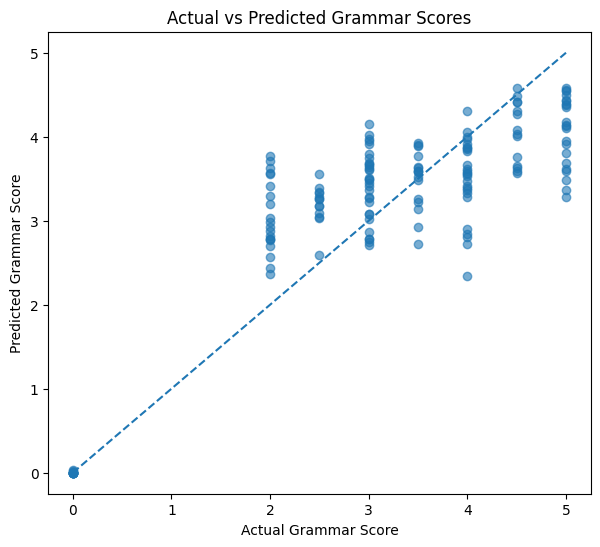

In [29]:
import matplotlib.pyplot as plt

plt.figure(figsize=(7, 6))

plt.scatter(
    y_val,
    y_pred,
    alpha=0.6
)

# Perfect prediction line
min_score = min(y_val.min(), y_pred.min())
max_score = max(y_val.max(), y_pred.max())

plt.plot(
    [min_score, max_score],
    [min_score, max_score],
    linestyle="--"
)

plt.xlabel("Actual Grammar Score")
plt.ylabel("Predicted Grammar Score")
plt.title("Actual vs Predicted Grammar Scores")

plt.show()

In [30]:
import pandas as pd
import matplotlib.pyplot as plt

# Get feature importance from Random Forest
importance_df = pd.DataFrame({
    "feature": X_train.columns,
    "importance": rf_model.feature_importances_
})

# Sort by importance
importance_df = importance_df.sort_values(
    by="importance",
    ascending=False
)

# Display top 15 features
print("Top 15 important features:")
display(importance_df.head(15))

Top 15 important features:


,feature,importance
3,mfcc_2_std,0.146343
0,mfcc_1_mean,0.117481
32,zero_crossing_mean,0.048572
5,mfcc_3_std,0.038243
9,mfcc_5_std,0.036635
13,mfcc_7_std,0.034081
1,mfcc_1_std,0.032781
7,mfcc_4_std,0.028912
4,mfcc_3_mean,0.028152
23,mfcc_12_std,0.028141


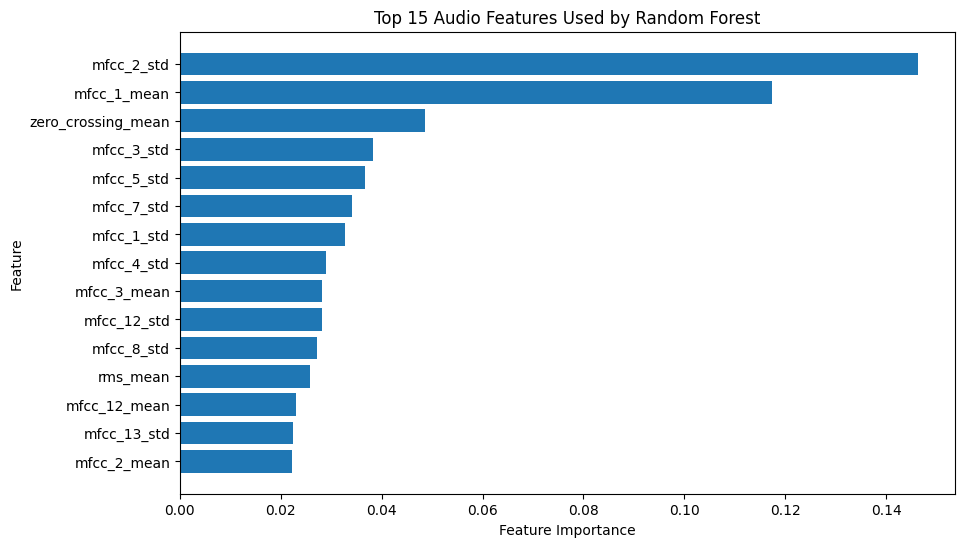

In [31]:
plt.figure(figsize=(10, 6))

top_features = importance_df.head(15).sort_values(
    by="importance"
)

plt.barh(
    top_features["feature"],
    top_features["importance"]
)

plt.xlabel("Feature Importance")
plt.ylabel("Feature")
plt.title("Top 15 Audio Features Used by Random Forest")

plt.show()

In [32]:
import torch
import importlib.util

print("CUDA available:", torch.cuda.is_available())

if torch.cuda.is_available():
    print("GPU:", torch.cuda.get_device_name(0))
else:
    print("Running on CPU")

print("Whisper installed:",
      importlib.util.find_spec("whisper") is not None)

print("faster-whisper installed:",
      importlib.util.find_spec("faster_whisper") is not None)

CUDA available: False
Running on CPU
Whisper installed: False
faster-whisper installed: False


In [33]:
!pip install -q faster-whisper

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.1/1.1 MB 21.2 MB/s eta 0:00:0000:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 35.0/35.0 MB 52.7 MB/s eta 0:00:00:00:0100:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 39.6/39.6 MB 33.1 MB/s eta 0:00:0000:0100:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 23.6/23.6 MB 47.3 MB/s eta 0:00:0000:0100:01


In [34]:
from faster_whisper import WhisperModel

print("faster-whisper installed successfully!")

faster-whisper installed successfully!


In [35]:
from faster_whisper import WhisperModel

print("Loading Whisper model...")

whisper_model = WhisperModel(
    "base.en",
    device="cpu",
    compute_type="int8"
)

print("Whisper model loaded successfully!")

Loading Whisper model...


Whisper model loaded successfully!


In [36]:
# Test Whisper transcription on one training audio

sample_filename = train.iloc[0]["filename"]
sample_path = os.path.join(TRAIN_AUDIO_PATH, sample_filename)

print("Transcribing:", sample_filename)

# Load audio ourselves
audio, sr = librosa.load(
    sample_path,
    sr=16000,
    mono=True
)

print("Audio sample rate:", sr)
print("Audio duration:", len(audio) / sr, "seconds")

# Transcribe the audio array
segments, info = whisper_model.transcribe(
    audio,
    beam_size=5
)

# Collect transcript
transcript = " ".join(
    segment.text.strip()
    for segment in segments
)

print("\nDetected language:", info.language)
print("Language probability:", info.language_probability)

print("\nTranscript:")
print(transcript)

Transcribing: audio_192.wav
Audio sample rate: 16000
Audio duration: 60.508375 seconds

Detected language: en
Language probability: 1

Transcript:
Well, the plateland is very, very beautiful and fun. There are little, like, the movement around the screen. The students usually enjoy the screen, it has to be like, um, it's more like a gimbal but hey, it won't sit for me and they would have, if not, would have to finish in the miracle round, which was kind of funny and, um, most of them play for, um, some parts, white or das, which is interesting, some of the kids like to do sand clashes and most times he had the sound of screaming children and laughing teeth.


In [37]:
import re
import numpy as np

def extract_text_features(text):
    """
    Extract simple linguistic features from a transcript.
    """

    # Clean text
    text = text.lower().strip()

    # Extract words
    words = re.findall(r"\b[a-z]+\b", text)

    # Basic counts
    word_count = len(words)
    unique_word_count = len(set(words))

    # Average word length
    if word_count > 0:
        avg_word_length = np.mean([
            len(word) for word in words
        ])
    else:
        avg_word_length = 0

    # Vocabulary diversity
    if word_count > 0:
        vocabulary_diversity = unique_word_count / word_count
    else:
        vocabulary_diversity = 0

    # Sentence estimation
    sentences = re.split(
        r"[.!?]+",
        text
    )

    sentences = [
        sentence.strip()
        for sentence in sentences
        if sentence.strip()
    ]

    sentence_count = len(sentences)

    # Average words per sentence
    if sentence_count > 0:
        avg_words_per_sentence = (
            word_count / sentence_count
        )
    else:
        avg_words_per_sentence = 0

    # Repeated words
    repeated_word_count = word_count - unique_word_count

    # Filler words
    filler_words = {
        "um",
        "uh",
        "er",
        "erm",
        "hmm",
        "like"
    }

    filler_count = sum(
        1 for word in words
        if word in filler_words
    )

    # Punctuation-based sentence boundaries
    punctuation_sentence_count = len(
        re.findall(r"[.!?]", text)
    )

    return {
        "word_count": word_count,
        "unique_word_count": unique_word_count,
        "avg_word_length": avg_word_length,
        "vocabulary_diversity": vocabulary_diversity,
        "sentence_count": sentence_count,
        "avg_words_per_sentence": avg_words_per_sentence,
        "repeated_word_count": repeated_word_count,
        "filler_count": filler_count,
        "punctuation_sentence_count": punctuation_sentence_count
    }

In [38]:
text_features = extract_text_features(transcript)

print("Number of linguistic features:", len(text_features))

display(
    pd.DataFrame([text_features])
)

Number of linguistic features: 9


,word_count,unique_word_count,avg_word_length,vocabulary_diversity,sentence_count,avg_words_per_sentence,repeated_word_count,filler_count,punctuation_sentence_count
0,101,69,3.930693,0.683168,3,33.666667,32,7,3


In [39]:
print("Filler count:",
      text_features["filler_count"])

print("Punctuation sentence count:",
      text_features["punctuation_sentence_count"])

Filler count: 7
Punctuation sentence count: 3


In [40]:
def transcribe_audio(audio_path):
    """
    Transcribe one audio file using Whisper.
    """

    audio, sr = librosa.load(
        audio_path,
        sr=16000,
        mono=True
    )

    segments, info = whisper_model.transcribe(
        audio,
        beam_size=5
    )

    text = " ".join(
        segment.text.strip()
        for segment in segments
    )

    return text

In [41]:
sample_transcript = transcribe_audio(sample_path)

print(sample_transcript)

Well, the plateland is very, very beautiful and fun. There are little, like, the movement around the screen. The students usually enjoy the screen, it has to be like, um, it's more like a gimbal but hey, it won't sit for me and they would have, if not, would have to finish in the miracle round, which was kind of funny and, um, most of them play for, um, some parts, white or das, which is interesting, some of the kids like to do sand clashes and most times he had the sound of screaming children and laughing teeth.


In [42]:
from tqdm.auto import tqdm
import os
import pandas as pd

transcript_file = "/kaggle/working/training_transcripts.csv"

# If a previous transcript file exists, resume from it
if os.path.exists(transcript_file):
    transcripts_df = pd.read_csv(transcript_file)
    completed_files = set(transcripts_df["filename"])
    print("Resuming from existing file.")
    print("Already completed:", len(completed_files))
else:
    transcripts_df = pd.DataFrame(
        columns=["filename", "transcript"]
    )
    completed_files = set()
    print("Starting transcription from the beginning.")

# Process training audio files
for _, row in tqdm(
    train.iterrows(),
    total=len(train),
    desc="Transcribing training audio"
):
    
    filename = row["filename"]

    # Skip files already completed
    if filename in completed_files:
        continue

    audio_path = os.path.join(
        TRAIN_AUDIO_PATH,
        filename
    )

    try:
        text = transcribe_audio(audio_path)

        new_row = pd.DataFrame([{
            "filename": filename,
            "transcript": text
        }])

        transcripts_df = pd.concat(
            [transcripts_df, new_row],
            ignore_index=True
        )

        # Save after every 10 files
        if len(transcripts_df) % 10 == 0:
            transcripts_df.to_csv(
                transcript_file,
                index=False
            )

    except Exception as e:
        print(f"\nError processing {filename}: {e}")

# Final save
transcripts_df.to_csv(
    transcript_file,
    index=False
)

print("\nTranscription complete!")
print("Number of transcripts:", len(transcripts_df))
print("Saved to:", transcript_file)

display(transcripts_df.head())

Starting transcription from the beginning.


Transcribing training audio:   0%|          | 0/769 [00:00<?, ?it/s]

KeyboardInterrupt: 

In [43]:
from tqdm.auto import tqdm

linguistic_features = []

for _, row in tqdm(
    transcripts_df.iterrows(),
    total=len(transcripts_df),
    desc="Extracting linguistic features"
):
    
    features = extract_text_features(
        row["transcript"]
    )
    
    features["filename"] = row["filename"]
    
    linguistic_features.append(features)

linguistic_features_df = pd.DataFrame(
    linguistic_features
)

print("Linguistic feature extraction complete!")
print("Shape:", linguistic_features_df.shape)

display(linguistic_features_df.head())

Extracting linguistic features:   0%|          | 0/21 [00:00<?, ?it/s]

Linguistic feature extraction complete!
Shape: (21, 10)


,word_count,unique_word_count,avg_word_length,vocabulary_diversity,sentence_count,avg_words_per_sentence,repeated_word_count,filler_count,punctuation_sentence_count,filename
0,101,69,3.930693,0.683168,3,33.666667,32,7,3,audio_192.wav
1,115,56,4.252174,0.486957,5,23.000000,59,6,5,audio_436.wav
2,147,77,4.013605,0.523810,12,12.250000,70,1,12,audio_447.wav
3,98,42,3.632653,0.428571,2,49.000000,56,0,2,audio_126.wav
4,75,44,3.733333,0.586667,5,15.000000,31,1,5,audio_61.wav


In [44]:
import pandas as pd

# Load the transcripts that we already generated
transcript_file = "/kaggle/working/training_transcripts.csv"

transcripts_df = pd.read_csv(transcript_file)

print("Transcripts loaded successfully!")
print("Shape:", transcripts_df.shape)

display(transcripts_df.head())

Transcripts loaded successfully!
Shape: (20, 2)


,filename,transcript
0,audio_192.wav,"Well, the plateland is very, very beautiful an..."
1,audio_436.wav,"The scene of a school playground, our playgrou..."
2,audio_447.wav,My favorite place to reject is the beach. I lo...
3,audio_126.wav,"Once upon a time, we, with 5 friends, went on ..."
4,audio_61.wav,"Well, when I was a child, I remember I went to..."


In [45]:
# Check which filename is missing from the transcripts

ling_files = set(linguistic_features_df["filename"])
transcript_files = set(transcripts_df["filename"])

print("Files in linguistic features but missing from transcripts:")
print(ling_files - transcript_files)

print("\nFiles in transcripts but missing from linguistic features:")
print(transcript_files - ling_files)

Files in linguistic features but missing from transcripts:
{'audio_77.wav'}

Files in transcripts but missing from linguistic features:
set()


In [46]:
# Transcribe the missing audio file only

missing_file = "audio_77.wav"
missing_audio_path = f"{BASE_PATH}/train/{missing_file}"

missing_transcript = transcribe_audio(missing_audio_path)

print("Filename:", missing_file)
print("\nTranscript:")
print(missing_transcript)

Filename: audio_77.wav

Transcript:
A school playground is one of the safest places that children are supposed to be. Security is supposed to be more on that side because most of the time they spend their time being on the playground. Anything can happen there and there's no one who would be able to take care of them. So I believe that a lot of security should be provided for the children in order for them to be safe enough and to be guided whenever there's a situation that will need a grown-up person's help.


In [48]:
# Add the missing transcript to transcripts_df

new_transcript_row = pd.DataFrame({
    "filename": ["audio_77.wav"],
    "transcript": [missing_transcript]
})

transcripts_df = pd.concat(
    [transcripts_df, new_transcript_row],
    ignore_index=True
)

print("Updated transcripts shape:", transcripts_df.shape)
print("\nLast row:")
display(transcripts_df.tail(1))

Updated transcripts shape: (22, 2)

Last row:


,filename,transcript
21,audio_77.wav,A school playground is one of the safest place...


In [49]:
# Check for duplicate filenames

duplicates = transcripts_df[
    transcripts_df["filename"].duplicated(keep=False)
].sort_values("filename")

print("Duplicate rows:")
display(duplicates)

Duplicate rows:


,filename,transcript
20,audio_77.wav,A school playground is one of the safest place...
21,audio_77.wav,A school playground is one of the safest place...


In [50]:
# Remove the duplicate transcript row

transcripts_df = transcripts_df.drop_duplicates(
    subset="filename",
    keep="first"
).reset_index(drop=True)

print("Updated transcripts shape:", transcripts_df.shape)
print("Unique filenames:", transcripts_df["filename"].nunique())

Updated transcripts shape: (21, 2)
Unique filenames: 21


In [51]:
# Verify that both datasets contain exactly the same files

ling_files = set(linguistic_features_df["filename"])
transcript_files = set(transcripts_df["filename"])

print("Linguistic feature files:", len(ling_files))
print("Transcript files:", len(transcript_files))

print("\nMissing from transcripts:", ling_files - transcript_files)
print("Extra in transcripts:", transcript_files - ling_files)

if ling_files == transcript_files:
    print("\n✅ Perfect! All filenames match exactly.")
else:
    print("\n⚠️ Filenames do not match.")

Linguistic feature files: 21
Transcript files: 21

Missing from transcripts: set()
Extra in transcripts: set()

✅ Perfect! All filenames match exactly.


In [61]:
# Merge acoustic and linguistic features using filename

combined_features_df = pd.merge(
    training_features_df,
    linguistic_features_df,
    on="filename",
    how="inner"
)

print("Combined dataset shape:", combined_features_df.shape)

display(combined_features_df.head())

Combined dataset shape: (21, 47)


,mfcc_1_mean,mfcc_1_std,mfcc_2_mean,mfcc_2_std,mfcc_3_mean,mfcc_3_std,mfcc_4_mean,mfcc_4_std,mfcc_5_mean,mfcc_5_std,...,label,word_count,unique_word_count,avg_word_length,vocabulary_diversity,sentence_count,avg_words_per_sentence,repeated_word_count,filler_count,punctuation_sentence_count
0,-388.503723,77.844963,73.002960,41.392876,-7.508863,22.981409,14.599792,15.307920,5.631713,7.427183,...,3.0,101,69,3.930693,0.683168,3,33.666667,32,7,3
1,-356.130127,57.372215,51.667614,38.211269,6.562364,29.172054,20.055347,22.314068,-6.827415,17.525940,...,3.0,115,56,4.252174,0.486957,5,23.000000,59,6,5
2,-365.827484,53.805023,60.606213,36.569939,12.393760,18.377462,7.660352,17.291498,3.903019,11.506568,...,3.5,147,77,4.013605,0.523810,12,12.250000,70,1,12
3,-387.141510,74.232559,70.404915,32.047825,9.073677,23.819502,24.759804,19.494772,9.365583,13.460578,...,2.0,98,42,3.632653,0.428571,2,49.000000,56,0,2
4,-350.781677,103.226501,37.082554,38.322483,-4.481045,23.882486,21.219343,22.429020,-2.818978,14.812812,...,2.0,75,44,3.733333,0.586667,5,15.000000,31,1,5


In [62]:
# Save the 21-sample combined feature dataset as a checkpoint

combined_features_df.to_csv(
    "/kaggle/working/combined_features_21.csv",
    index=False
)

print("Checkpoint saved successfully.")
print("Shape:", combined_features_df.shape)

Checkpoint saved successfully.
Shape: (21, 47)


In [63]:
import os

print("Files in /kaggle/working:\n")

for file in os.listdir("/kaggle/working"):
    print(file)

Files in /kaggle/working:

combined_features_21.csv
training_transcripts.csv
training_audio_features.csv
.virtual_documents


In [64]:
# Load the completed transcript file and verify it

training_transcripts = pd.read_csv(
    "/kaggle/working/training_transcripts.csv"
)

print("Transcript dataset shape:", training_transcripts.shape)
print("Unique filenames:", training_transcripts["filename"].nunique())

print("\nFirst 5 rows:")
display(training_transcripts.head())

Transcript dataset shape: (20, 2)
Unique filenames: 20

First 5 rows:


,filename,transcript
0,audio_192.wav,"Well, the plateland is very, very beautiful an..."
1,audio_436.wav,"The scene of a school playground, our playgrou..."
2,audio_447.wav,My favorite place to reject is the beach. I lo...
3,audio_126.wav,"Once upon a time, we, with 5 friends, went on ..."
4,audio_61.wav,"Well, when I was a child, I remember I went to..."


In [65]:
# Save the corrected 21 transcripts as a separate checkpoint

transcripts_df.to_csv(
    "/kaggle/working/training_transcripts_21.csv",
    index=False
)

print("Saved corrected transcript checkpoint.")
print("Shape:", transcripts_df.shape)

Saved corrected transcript checkpoint.
Shape: (21, 2)


In [68]:
import os
import pandas as pd
import librosa

checkpoint_path = "/kaggle/working/training_transcripts_progress.csv"

def transcribe_with_checkpoint(audio_files, audio_folder, checkpoint_every=10):
    """
    Transcribe audio files and save progress every few files.
    Existing transcripts are skipped automatically.
    """

    # Load existing progress if available
    if os.path.exists(checkpoint_path):
        progress_df = pd.read_csv(checkpoint_path)
        transcripts_dict = dict(
            zip(progress_df["filename"], progress_df["transcript"])
        )
        print(f"Loaded {len(transcripts_dict)} existing transcripts.")
    else:
        transcripts_dict = {}
        print("Starting new transcription process.")

    total_files = len(audio_files)

    for i, filename in enumerate(audio_files, start=1):

        # Skip files already transcribed
        if filename in transcripts_dict:
            continue

        audio_path = os.path.join(audio_folder, filename)

        try:
            audio, sr = librosa.load(
                audio_path,
                sr=16000,
                mono=True
            )

            segments, info = whisper_model.transcribe(
                audio,
                beam_size=5
            )

            transcript = " ".join(
                segment.text.strip()
                for segment in segments
            )

            transcripts_dict[filename] = transcript

        except Exception as e:
            print(f"Error processing {filename}: {e}")
            continue

        # Save checkpoint
        if len(transcripts_dict) % checkpoint_every == 0:
            progress_df = pd.DataFrame(
                list(transcripts_dict.items()),
                columns=["filename", "transcript"]
            )

            progress_df.to_csv(
                checkpoint_path,
                index=False
            )

            print(
                f"Checkpoint saved: "
                f"{len(transcripts_dict)}/{total_files}"
            )

    # Final save
    progress_df = pd.DataFrame(
        list(transcripts_dict.items()),
        columns=["filename", "transcript"]
    )

    progress_df.to_csv(
        checkpoint_path,
        index=False
    )

    print("\nTranscription complete!")
    print("Total transcripts:", len(progress_df))

    return progress_df

In [ ]:
# Prepare the list of all training audio files

train_audio_folder = f"{BASE_PATH}/train"

audio_files = sorted([
    file for file in os.listdir(train_audio_folder)
    if file.lower().endswith(".wav")
])

print("Total training audio files:", len(audio_files))
print("First 5 files:", audio_files[:5])

In [ ]:
# Start checkpointed transcription
# Existing transcripts will be reused automatically.

training_transcripts_full = transcribe_with_checkpoint(
    audio_files=audio_files,
    audio_folder=train_audio_folder,
    checkpoint_every=10
)